# 0. OpenAI Gym Intorduction

OpenAI Gym is a package for building, evaluating and comparing RL algorithms. It is compatible with algorithms written in any frameworks like TensoFlow, Pytorch, etc. It is simple and easy to comprehend. Documentation can be found here:

https://gym.openai.com

https://github.com/openai/gym

Open AI Gym defines many environemnts, such as CartPole, running Cheeta, Atari games, and others. 
For each environemt, it defines 

1- **Action and State spaces**: A gym environment has to define its action and state space via two members, action space and observation space. For example, is the space discrete or continous? If it is discrete, how many values can it take? etc. The action and state spaces are defined once you instantiate the environment (i.e., inside the __init__() method). The different spaces that Gym allows for are

* **Discrete**: A discrete space in $\{ 0, 1, \dots, n-1 \}$
* **Box**: A (possibly unbounded) box in $R^n$. Specifically, a Box represents the Cartesian product of $n$ closed intervals. Each interval has the form of one of $[a, b]$, $(-oo, b]$, $[a, oo)$, or $(-oo, oo)$
* **MultiDiscrete**: The multi-discrete action space consists of a series of discrete action spaces with different number of actions in each. It is useful e.g. to represent game controllers or keyboards where each key can be represented as a discrete action space
* **MultiBinary**: $n$-dimensional Binary space


2- How an agent can interact with the environemnt. For that it defined the following methods
* **reset()** : This method should reset the environment state to a possible start state, and return the observation for this state. It takes no arguments.

* **step(action)** : It takes the "action" as an argument. This method should simulate the environment dynamics and the agent’s actions in one time step. It returns a tuple (observation, reward, done, info) that describes the transition. (1) observation is the information the agent perceives about the new (next) state. (2) reward is the reward that the agent is assigned in the new state. (3) done is True if the next state is a terminal state, False otherwise. (4) info is a list or dictionary that contains additional (debug) information about the environment – for now, you can assume it is an empty dictionary ({}).

* **render()** : This is a helper method that visualizes the current state in a human- or agent-readable way.

# 1. Get into action

Let's see an example using Cartpole environment (see documentation here https://gymnasium.farama.org/environments/classic_control/cart_pole/ )

We will follow these steps

* Import Gym and Create the Environment
* Understand the state and action spaces
* Initialize the Environment 
* Excute one simulation step
* Visulaize the environemnt 
* Close the environemnt

In [35]:
pip install gymnasium


[notice] A new release of pip is available: 23.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# pip install gym[classic_control]

In [37]:
import gymnasium as gym
env = gym.make('CartPole-v1')

In [39]:
print("** Observation Space Details **")
print("CartPole-v1, Observation Space--\n" +str(env.observation_space))
print("Observation Space high:" +str(env.observation_space.high))
print("Observation Space low:" +str(env.observation_space.low))

** Observation Space Details **
CartPole-v1, Observation Space--
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation Space high:[4.8               inf 0.41887903        inf]
Observation Space low:[-4.8               -inf -0.41887903        -inf]


**The state (observation) of Cartpole is four dimensional. Each component in the state vector is a continous number that has a lower bound and higher bound.**

**Each component represent something about the state of the cart, i.e., Cart Position, Cart Velocity, Pole Angle, Pole Angular Velocity.**

In [40]:
# Print Action Space space detail ------------------------
print("** Action Space Details **")
print("CartPole-v1, Action Space--\n"+str(env.action_space))

** Action Space Details **
CartPole-v1, Action Space--
Discrete(2)


**The action of Cartpole is discrete and can take one of two values, i.e., binary. Agent can go left or right.**

In [44]:
# Let's reset the environemnt and get the starting state
obs, _ = env.reset()
print(obs)

[-0.0280015   0.02973612 -0.00431147  0.01852114]


In [48]:
# To process, we need to select an action. We can sample a random action via .sample()
action = env.action_space.sample()
print("Old states = " + str(obs))
print("Action = " + str(action))

Old states = [-0.0280015   0.02973612 -0.00431147  0.01852114]
Action = 0


In [49]:
## Let's do one step in the environment with the selected action
next_obs, reward, terminate, truncate, _ = env.step(action)
print("New state = " + str(next_obs))
print("Reward = " + str(reward))
print("Is done? = " + str(terminate or truncate))

New state = [-0.02740678 -0.16532373 -0.00394105  0.30984065]
Reward = 1.0
Is done? = False


C:\Users\husse\AppData\Local\Programs\Python\Python310\lib\site-packages\gymnasium\envs\classic_control\cartpole.py:250: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


TypeError: Image data of dtype object cannot be converted to float

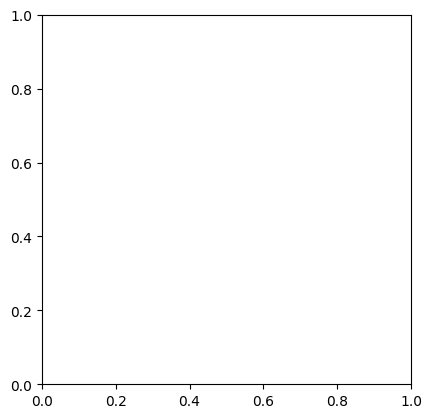

In [50]:
# Visualize the environemnt
import matplotlib.pyplot as plt 
img = env.render()
plt.imshow(img)

In [ ]:
env.close()

## Write a code to simulate 10 trajectories in CartPole environment

**Print average sum of rewards across episodes (trajectories)** 

In [51]:
import torch
import numpy as np

In [1]:
def sample_n_trajectories(env: gym.Env, num_trajectories: int):
    
    trajectories = {}
    
    obs = []
    next_obs = []
    actions = []
    rewards = []
    terminals = []
    for _ in range(num_trajectories):
        trajectory = sample_trajectory(env)
        obs.append(trajectory['obs'])
        next_obs.append(trajectory['next_obs'])
        rewards.append(trajectory['rewards'])
        actions.append(trajectory['actions'])
        terminals.append(trajectory['terminals'])

    trajectories['obs'] = obs # list of length n, each element is a tensor of size (num_steps_per_trajectory, obs_dim)
    trajectories['next_obs'] = next_obs # list of length n, each element is a tensor of size (num_steps_per_trajectory, obs_dim)
    trajectories['actions'] = actions # list of length n, each element is a tensor of size (num_steps_per_trajectory, action_dim)
    trajectories['rewards'] = rewards # list of length n, each element is a tensor of size (num_steps_per_trajectory)
    trajectories['terminals'] = terminals # list of length n, each element is a tensor of size (num_steps_per_trajectory)

    return trajectories

    
    
def sample_trajectory(env: gym.Env):
    obs = []
    next_obs = []
    actions = []
    rewards = []
    terminals = []
    
    ob, _ = env.reset()
    while True:
        action = env.action_space.sample()
        next_ob, rew, terminated, truncated, info = env.step(action)
        rollout_done = terminated or truncated
        
        obs.append(torch.FloatTensor(ob))
        next_obs.append(torch.FloatTensor(next_ob))
        rewards.append(torch.tensor([rew], dtype=float))
        actions.append(torch.tensor([action], dtype=float))
        terminals.append(torch.tensor([rollout_done], dtype=bool))
        
        if rollout_done:
            break
        
        ob = next_ob
    
    trajectory = {}
    trajectory['obs'] = torch.stack(obs, dim=0) # (num_steps_per_trajectory, obs_dim)
    trajectory['next_obs'] = torch.stack(obs, dim=0) # (num_steps_per_trajectory, obs_dim)
    trajectory['rewards'] = torch.stack(rewards, dim=0).squeeze(1) # (num_steps_per_trajectory)
    trajectory['actions'] = torch.stack(actions, dim=0) # (num_steps_per_trajectory, action_dim)
    trajectory['terminals'] = torch.stack(terminals, dim=0).squeeze(1) # (num_steps_per_trajectory)
    
    return trajectory

NameError: name 'gym' is not defined

In [ ]:
env_pole = gym.make('CartPole-v1')
trajectories = sample_n_trajectories(env=env_pole, num_trajectories=10)

In [54]:
trajectories['rewards'][0]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1.], dtype=torch.float64)

In [55]:
returns = [torch.sum(traj_rewards).item() for traj_rewards in trajectories['rewards']]
avg_sum_rewards, std_sum_rewards = np.mean(returns), np.std(returns)
print(f"### Average, std sum of rewards is {avg_sum_rewards}, {std_sum_rewards}")

### Average, std sum of rewards is 28.4, 14.079772725438435


In [34]:
env_pole.close()